## Using the Automated Method created to pinpoint times of fault and failures (i.e. anomalies) in machines.

In [5]:
import sys
import os

# Yo code le Site1 folder lai Python ko path ma thapxa
sys.path.append(os.path.abspath(''))
print("Current Path:", os.getcwd())

Current Path: c:\Users\dell\Downloads\Report_Projects\Site1


In [6]:
from training import automated_training

In [7]:
trn = automated_training( input_data = 'machine_1.csv', window_size = 25, time_steps = 21, learning_rate = 0.0001, 
                         epoch = 200, batch_size = 64, sc_filepath = 'sc_model.bin', lstm_filepath = 'lstm_model.h5', 
                         thres_filepath = 'threshold.npy')

***The following parameters supplied for the automated training method is required for training of the LSTM model on the proposed dataset that would be used for training***

- Note: This automated method saves the **Scaler Model, LSTM Autoencoder Model and Threshold into different output files,** this is because these files will be required to pinpoint times of faults and failures in the future data sets given to this model.

- If the dataset is said to expand i.e. greater than 3000, the LSTM model will need to be retrained with a larger dataset since this model was only trained on the available dataset. 

- Also, we only use the 4 features / variables for each of the machines, we could have concatenated the features of all the 19 machines in the data repository but we noticed that the machines are different as a result they will react differently to the model, so sticking to one machine is required.

In [8]:
trn.LSTM_training()

Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - loss: 0.9450 - val_loss: 1.3322
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.9422 - val_loss: 1.3278
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.9384 - val_loss: 1.3198
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.9323 - val_loss: 1.3060
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.9215 - val_loss: 1.2823
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 1.0696 - val_loss: 1.2891
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.9126 - val_loss: 1.2863
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.9096 - val_loss: 1.2824
Epoch 9/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.9059 - val_loss: 1.2780
Epoch 10/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.9011 - val_loss: 1.2728
Epoch 11/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.8942 - val_loss: 1.2661
Epoch 12/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/st

In [24]:
from anomaly_detection import automated_prediction

In [10]:
prd = automated_prediction(input_data = 'machine_2.csv', window_size = 25, time_steps = 21, 
                            scaler_filepath = 'sc_model.bin', lstm_filepath = 'lstm_model.h5', 
                            thres_filepath = 'threshold.npy')

***Here, I used the model trained on machine_1 dataset to predict times of anomalies / pinpoint times of fault and failures in machine_2 and machine_19, this should be ideally used for the future version of machine 1.***

- Normally, The trained method should be used on future version of machine 1 but in this case since we currently dont have future version of machine 1 will decided to predict on machine 2 based on what our model has learnt on machine 1.


- Lets further use it to pinpoint times of anomalies in machine 19

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step


,Loss_mae,Threshold,Anomaly
2019-05-17,1.339144,1.31,True
2019-05-18,1.346861,1.31,True
2019-05-18,1.429926,1.31,True
2019-05-19,1.361425,1.31,True
2019-05-20,1.510286,1.31,True
2019-05-22,1.384275,1.31,True
2019-05-23,1.411840,1.31,True
2019-05-23,1.430458,1.31,True
2019-05-23,1.350148,1.31,True
2019-09-29,1.670605,1.31,True


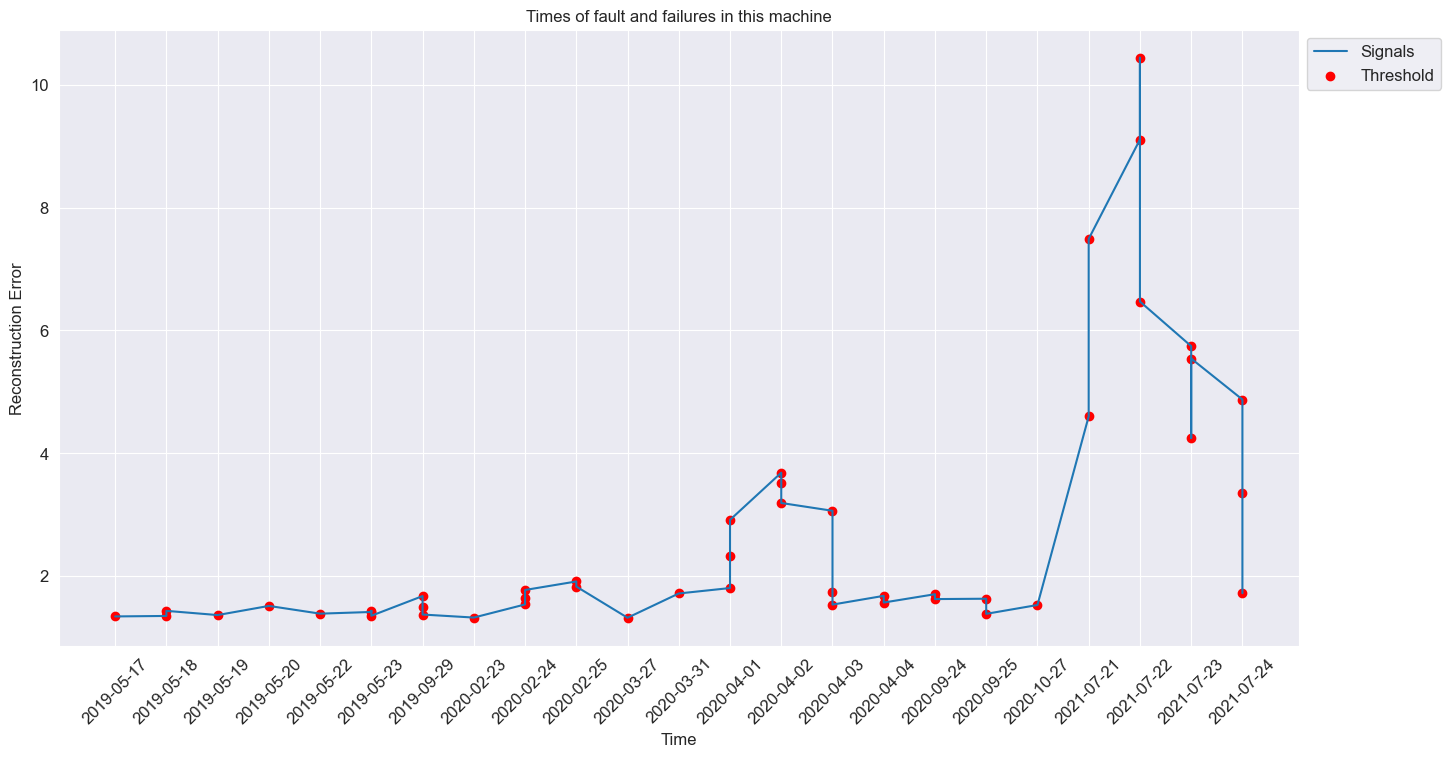

In [11]:
prd.LSTM_prediction()

In [12]:
prd = automated_prediction(input_data = 'machine_19.csv', window_size = 25, time_steps = 21, 
                            scaler_filepath = 'sc_model.bin', lstm_filepath = 'lstm_model.h5', 
                            thres_filepath = 'threshold.npy')

In [25]:
prd = automated_prediction(
    input_data="machine_0.csv",
    window_size=5,
    time_steps=10,
    scaler_filepath="sc_model.bin",
    lstm_filepath="lstm_model.h5",
    thres_filepath="threshold.npy"
)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step


,Loss_mae,Threshold,Anomaly
2019-01-04,3.319441,1.31,True
2019-01-05,4.093303,1.31,True
2019-01-05,3.663175,1.31,True
2019-01-05,2.088205,1.31,True
2019-01-06,1.661783,1.31,True
...,...,...,...
2021-09-24,2.507010,1.31,True
2021-09-24,2.338314,1.31,True
2021-09-25,2.166673,1.31,True
2021-09-25,2.053814,1.31,True


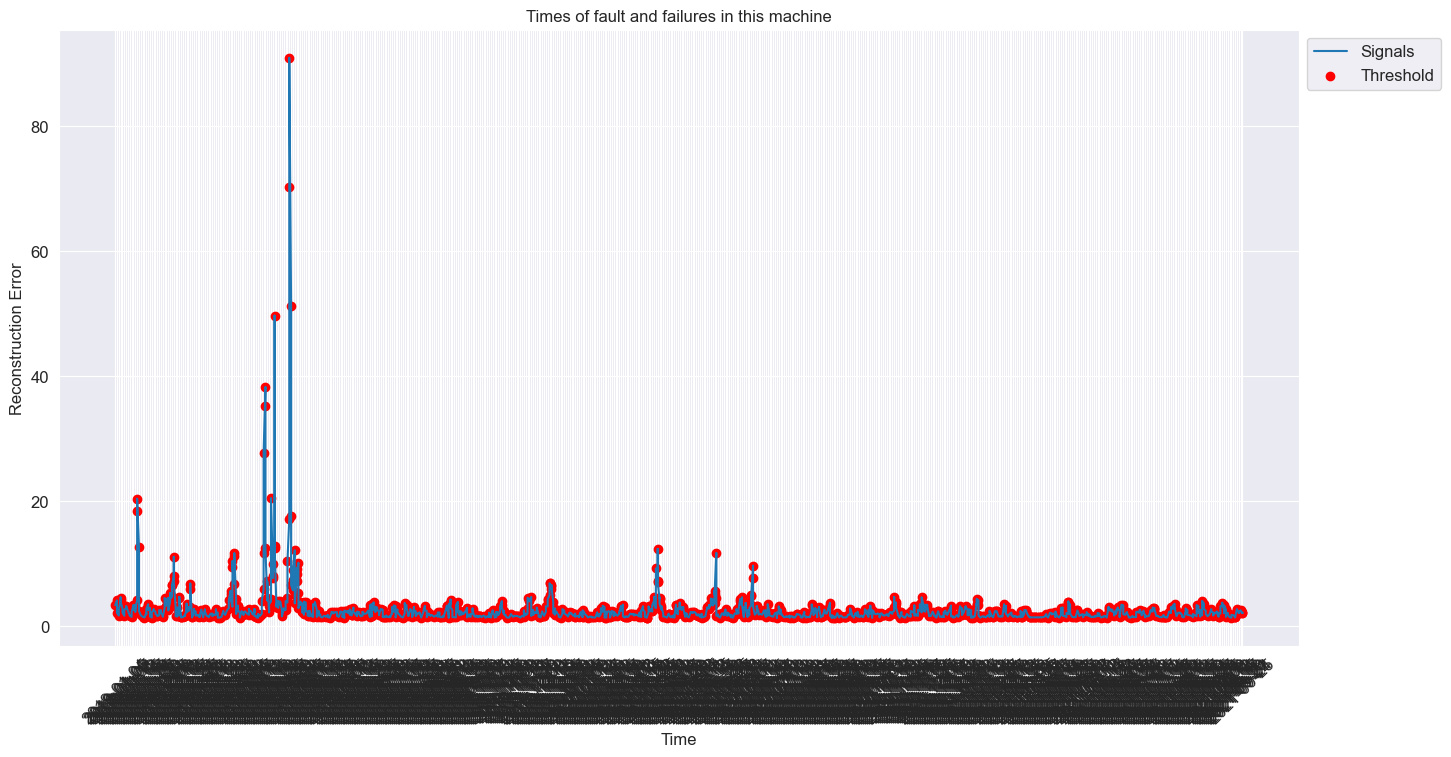

In [26]:
prd.LSTM_prediction()

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


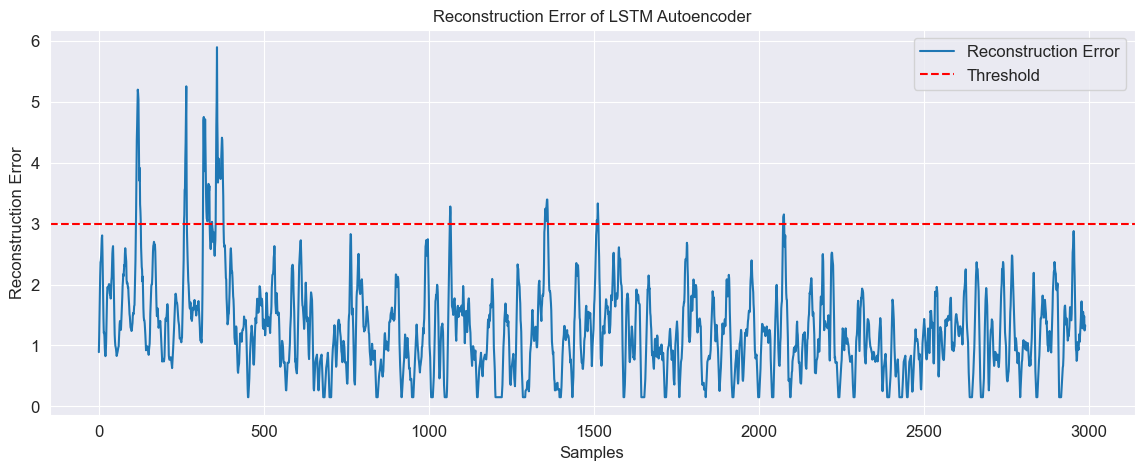

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Predict reconstructed signals
reconstructed = prd.lstm_model.predict(prd.lstm_input)

# Match shapes
min_timesteps = min(reconstructed.shape[1], prd.lstm_input.shape[1])

# Trim both arrays
reconstructed_trim = reconstructed[:, :min_timesteps, :]
input_trim = prd.lstm_input[:, :min_timesteps, :]

# Reconstruction Error
reconstruction_error = np.mean(
    np.abs(reconstructed_trim - input_trim),
    axis=(1,2)
)

# Threshold
threshold = 3

# Plot
plt.figure(figsize=(14,5))

plt.plot(reconstruction_error, label="Reconstruction Error")

# Threshold line
plt.axhline(
    y=threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)

plt.title("Reconstruction Error of LSTM Autoencoder")
plt.xlabel("Samples")
plt.ylabel("Reconstruction Error")

plt.legend()

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict reconstructed signals
reconstructed = prd.lstm_model.predict(prd.lstm_input)

# Match shapes
min_timesteps = min(reconstructed.shape[1], prd.lstm_input.shape[1])

reconstructed_trim = reconstructed[:, :min_timesteps, :]
input_trim = prd.lstm_input[:, :min_timesteps, :]

# Feature-wise reconstruction error
feature_error = np.mean(
    np.abs(reconstructed_trim - input_trim),
    axis=(0,1)
)

# Sensor names
raw_data = pd.read_csv(prd.input_data, index_col=0)
sensor_names = raw_data.columns.tolist()

# Plot
plt.figure(figsize=(10,5))

plt.bar(sensor_names, feature_error)

plt.title("Feature-wise Reconstruction Error")
plt.xlabel("Sensors")
plt.ylabel("Average Error")

plt.show()

TypeError: 'numpy.ndarray' object is not callable